# Protein Mutation Analyzer

## Project Overview

Protein mutations can alter amino-acid composition, physicochemical properties, and potentially the structural or functional behavior of proteins.

In this project, we develop a reusable Python-based workflow for comparing a wild-type protein sequence with a mutant protein sequence.

The analysis uses the human TP53 protein as a real biological example. The reference protein is TP53 (UniProtKB P04637), a reviewed human protein consisting of 393 amino acids. A documented TP53 variant, p.Arg175His (R175H), is used as the mutant example. The variant is recorded in ClinVar as a change from arginine to histidine at protein position 175.

The purpose of this project is not to predict clinical outcomes directly. Instead, the workflow focuses on computational characterization of the protein sequence change.

## Objectives

The main objectives are to:

1. Obtain a real protein reference sequence from UniProt.
2. Create a mutant protein sequence corresponding to a documented amino-acid variant.
3. Compare wild-type and mutant protein sequences.
4. Identify amino-acid substitutions.
5. Detect insertions and deletions when present.
6. Compare basic physicochemical properties of the protein sequences.
7. Characterize the amino-acid substitution using residue properties.
8. Visualize mutation position and property changes.
9. Generate a structured mutation report.
10. Export the analysis results for further use.

## Biological Example

**Protein:** TP53
**UniProt accession:** P04637
**Organism:** Homo sapiens
**Reference length:** 393 amino acids
**Variant:** p.Arg175His (R175H)

The project is designed to be reusable. Although TP53 is used as the demonstration dataset, the analysis functions are intended to work with other protein sequences and protein variants.

## Important Scope

This project is **protein-only**.

It does not perform:

* DNA sequence analysis
* nucleotide mutation analysis
* DNA-to-protein translation
* codon analysis
* synonymous/missense/nonsense classification at the nucleotide level

The focus is entirely on comparing protein sequences and characterizing amino-acid changes.

## Workflow

**Reference protein → Mutant protein → Sequence comparison → Mutation detection → Property analysis → Visualization → Report**


## 1. Environment Setup


We will install and import the Python packages required for protein sequence analysis.


The project uses Biopython for biological sequence handling and protein-property calculations, while pandas and matplotlib are used for structured analysis and visualization.

### Main packages

* **Biopython** — protein sequence handling and analysis
* **pandas** — structured data analysis
* **matplotlib** — visualization
* **requests** — retrieving the reference protein sequence from UniProt


In [1]:
!pip install biopython pandas matplotlib requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.5 MB/s eta 0:00:00


In [2]:
import Bio
import pandas as pd
import matplotlib.pyplot as plt
import requests
import numpy as np

from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.SeqUtils.ProtParam import ProteinAnalysis

print("Biopython version:", Bio.__version__)
print("Pandas version:", pd.__version__)
print("Environment ready!")

Biopython version: 1.88
Pandas version: 2.2.3
Environment ready!


## 2. Configuration


We will define the biological reference and variant used in this analysis.

### Reference protein

The reference protein is human TP53:

* UniProt accession: P04637
* Protein name: Cellular tumor antigen p53
* Organism: Homo sapiens

### Variant

The protein variant analyzed in this project is:

**p.Arg175His (R175H)**

This represents a substitution of arginine (R) by histidine (H) at amino-acid position 175.

The variant is documented in ClinVar under TP53 and is linked to UniProt protein accession P04637.

The sequence analysis in this notebook will focus on the protein-level change.


In [3]:
UNIPROT_ID = "P04637"

WILDTYPE_AA = "R"
MUTANT_AA = "H"
MUTATION_POSITION = 175

VARIANT_NAME = "p.Arg175His (R175H)"

print("Reference protein:", UNIPROT_ID)
print("Variant:", VARIANT_NAME)
print("Position:", MUTATION_POSITION)

Reference protein: P04637
Variant: p.Arg175His (R175H)
Position: 175


## 3. Retrieve the Reference Protein



We will retrieve the TP53 reference protein sequence directly from the UniProt REST service.



Using a public biological database rather than manually typing a protein sequence makes the workflow reproducible and reduces the possibility of transcription errors.

The sequence will be retrieved in FASTA format and parsed using Biopython.



In [4]:
uniprot_url = f"https://rest.uniprot.org/uniprotkb/{UNIPROT_ID}.fasta"

response = requests.get(uniprot_url, timeout=30)
response.raise_for_status()

fasta_text = response.text

print("UniProt sequence retrieved successfully.")
print(fasta_text[:300])

UniProt sequence retrieved successfully.
>sp|P04637|P53_HUMAN Cellular tumor antigen p53 OS=Homo sapiens OX=9606 GN=TP53 PE=1 SV=4
MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGP
DEAPRMPEAAPPVAPAPAAPTPAAPAPAPSWPLSSSVPSQKTYQGSYGFRLGFLHSGTAK
SVTCTYSPALNKMFCQLAKTCPVQLWVDSTPPPGTRVRAMAIYKQSQHMTEVVRRCPHHE
RCSDSDGLAPPQHLIRVEGNLRVEYLD


In [5]:
from io import StringIO

record = SeqIO.read(
    StringIO(fasta_text),
    "fasta"
)

wildtype_sequence = str(record.seq)

print("Protein ID:", record.id)
print("Description:", record.description)
print("Sequence length:", len(wildtype_sequence))

Protein ID: sp|P04637|P53_HUMAN
Description: sp|P04637|P53_HUMAN Cellular tumor antigen p53 OS=Homo sapiens OX=9606 GN=TP53 PE=1 SV=4
Sequence length: 393


## 4. Inspecting the Reference Protein



We will inspect basic information about the retrieved TP53 sequence.



Before performing mutation analysis, it is important to verify that the sequence was successfully retrieved and that its length and identifier are consistent with the expected reference protein.

We will also inspect the region surrounding the mutation position.


In [6]:
print("Protein:", record.id)
print("Length:", len(wildtype_sequence))
print("\nFirst 60 amino acids:")
print(wildtype_sequence[:60])

Protein: sp|P04637|P53_HUMAN
Length: 393

First 60 amino acids:
MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGP


In [7]:
start = MUTATION_POSITION - 6
end = MUTATION_POSITION + 5

print("Sequence region surrounding position 175:")
print(wildtype_sequence[start:end])

print("\nResidue at position 175:")
print(wildtype_sequence[MUTATION_POSITION - 1])

Sequence region surrounding position 175:
TEVVRRCPHHE

Residue at position 175:
R


## 5. Verify the Mutation Position


We will confirm that amino-acid position 175 in the UniProt reference sequence contains arginine (R), as expected for the p.Arg175His variant.



A mutation should never be applied blindly to a sequence.

Before generating the mutant sequence, the program should verify that:

**Reference residue = expected wild-type residue**

This is an important validation step in a reusable mutation-analysis workflow.


In [8]:
observed_residue = wildtype_sequence[MUTATION_POSITION - 1]

print("Expected residue:", WILDTYPE_AA)
print("Observed residue:", observed_residue)

if observed_residue == WILDTYPE_AA:
    print("Validation successful: reference residue matches.")
else:
    raise ValueError(
        f"Reference mismatch: expected {WILDTYPE_AA}, "
        f"but found {observed_residue}."
    )

Expected residue: R
Observed residue: R
Validation successful: reference residue matches.


## 6. Generate the Mutant Protein Sequence


We will generate the mutant TP53 protein sequence by replacing the amino acid at position 175:

**R → H**

The sequence length remains unchanged because this is a single amino-acid substitution.


A mutation analyzer needs both the reference and altered protein sequences so that the two can be compared computationally.

The original wild-type sequence will be preserved.


In [9]:
mutant_sequence = (
    wildtype_sequence[:MUTATION_POSITION - 1]
    + MUTANT_AA
    + wildtype_sequence[MUTATION_POSITION:]
)

print("Wild-type length:", len(wildtype_sequence))
print("Mutant length:", len(mutant_sequence))

Wild-type length: 393
Mutant length: 393


In [10]:
print("Wild-type residue:")
print(wildtype_sequence[MUTATION_POSITION - 1])

print("\nMutant residue:")
print(mutant_sequence[MUTATION_POSITION - 1])

Wild-type residue:
R

Mutant residue:
H


## 7. Validate the Mutant Sequence



We will confirm that the mutation was introduced at the intended position and that all other sequence positions remain unchanged.



A robust computational workflow should verify its own modifications.

For a single amino-acid substitution:

* sequence lengths should remain equal
* exactly one position should differ
* the changed position should correspond to the requested mutation


In [11]:
differences = []

for i, (wt, mut) in enumerate(
    zip(wildtype_sequence, mutant_sequence),
    start=1
):
    if wt != mut:
        differences.append({
            "Position": i,
            "Wild_Type": wt,
            "Mutant": mut
        })

difference_df = pd.DataFrame(differences)

display(difference_df)

,Position,Wild_Type,Mutant
0,175,R,H


In [12]:
assert len(wildtype_sequence) == len(mutant_sequence)
assert len(differences) == 1
assert differences[0]["Position"] == MUTATION_POSITION

print("Mutation validation successful.")

Mutation validation successful.


## 8. Reusable Protein Mutation Detection


We will create a general function that compares two protein sequences and identifies amino-acid differences.

A reusable bioinformatics tool should not depend on one specific protein.

The function should work with other wild-type and mutant protein sequences provided by the user.

The comparison will report:

* mutation position
* wild-type amino acid
* mutant amino acid
* mutation type

For sequences of equal length, differences are treated as substitutions. Length differences are reported separately for possible insertions or deletions.


In [13]:
def compare_proteins(wildtype, mutant):
    """
    Compare wild-type and mutant protein sequences.

    Returns:
        list of dictionaries describing substitutions.
    """

    differences = []

    min_length = min(len(wildtype), len(mutant))

    for i in range(min_length):
        if wildtype[i] != mutant[i]:
            differences.append({
                "Position": i + 1,
                "Wild_Type": wildtype[i],
                "Mutant": mutant[i],
                "Mutation_Type": "Substitution"
            })

    return differences

In [14]:
mutation_results = compare_proteins(
    wildtype_sequence,
    mutant_sequence
)

mutation_df = pd.DataFrame(mutation_results)

display(mutation_df)

,Position,Wild_Type,Mutant,Mutation_Type
0,175,R,H,Substitution


## 9. Insertion and Deletion Detection



We will compare the lengths of the wild-type and mutant proteins.



Protein variants are not always simple substitutions. Insertions and deletions can change the length of a protein sequence.

For the current TP53 R175H example, no insertion or deletion is expected because R175H is a single-residue substitution.

The workflow nevertheless includes length checking so that it can be extended to other protein variants.


In [15]:
length_difference = len(mutant_sequence) - len(wildtype_sequence)

print("Wild-type length:", len(wildtype_sequence))
print("Mutant length:", len(mutant_sequence))
print("Length difference:", length_difference)

if length_difference == 0:
    print("No length change detected.")
elif length_difference > 0:
    print(f"Possible insertion of {length_difference} residue(s).")
else:
    print(f"Possible deletion of {abs(length_difference)} residue(s).")

Wild-type length: 393
Mutant length: 393
Length difference: 0
No length change detected.


## 10. Amino-Acid Property Analysis


We will characterize the amino acids involved in the mutation using basic biochemical properties.

For this project, we will examine:

* Molecular weight
* Charge category
* Polarity
* Hydrophobicity


An amino-acid substitution can change biochemical properties even when the overall protein length remains unchanged.

Comparing residue properties provides a computational description of how the substituted amino acids differ.

These measurements describe sequence-level physicochemical changes and should not be interpreted as direct proof of altered protein function.


In [16]:
amino_acid_properties = {
    "A": {"name": "Alanine", "charge": "nonpolar", "polarity": "nonpolar"},
    "R": {"name": "Arginine", "charge": "positive", "polarity": "polar"},
    "N": {"name": "Asparagine", "charge": "neutral", "polarity": "polar"},
    "D": {"name": "Aspartic acid", "charge": "negative", "polarity": "polar"},
    "C": {"name": "Cysteine", "charge": "neutral", "polarity": "polar"},
    "E": {"name": "Glutamic acid", "charge": "negative", "polarity": "polar"},
    "Q": {"name": "Glutamine", "charge": "neutral", "polarity": "polar"},
    "G": {"name": "Glycine", "charge": "nonpolar", "polarity": "nonpolar"},
    "H": {"name": "Histidine", "charge": "positive", "polarity": "polar"},
    "I": {"name": "Isoleucine", "charge": "nonpolar", "polarity": "nonpolar"},
    "L": {"name": "Leucine", "charge": "nonpolar", "polarity": "nonpolar"},
    "K": {"name": "Lysine", "charge": "positive", "polarity": "polar"},
    "M": {"name": "Methionine", "charge": "nonpolar", "polarity": "nonpolar"},
    "F": {"name": "Phenylalanine", "charge": "nonpolar", "polarity": "nonpolar"},
    "P": {"name": "Proline", "charge": "nonpolar", "polarity": "nonpolar"},
    "S": {"name": "Serine", "charge": "neutral", "polarity": "polar"},
    "T": {"name": "Threonine", "charge": "neutral", "polarity": "polar"},
    "W": {"name": "Tryptophan", "charge": "nonpolar", "polarity": "nonpolar"},
    "Y": {"name": "Tyrosine", "charge": "neutral", "polarity": "polar"},
    "V": {"name": "Valine", "charge": "nonpolar", "polarity": "nonpolar"}
}

In [17]:
wt_aa = WILDTYPE_AA
mut_aa = MUTANT_AA

wt_properties = amino_acid_properties[wt_aa]
mut_properties = amino_acid_properties[mut_aa]

print("Wild-type amino acid")
print("--------------------")
print(wt_aa, "-", wt_properties)

print("\nMutant amino acid")
print("-----------------")
print(mut_aa, "-", mut_properties)

Wild-type amino acid
--------------------
R - {'name': 'Arginine', 'charge': 'positive', 'polarity': 'polar'}

Mutant amino acid
-----------------
H - {'name': 'Histidine', 'charge': 'positive', 'polarity': 'polar'}



We will compare numerical and biochemical properties of the wild-type and mutant amino acids involved in the mutation.

For the TP53 R175H variant, the comparison is between:

- Arginine (R) — wild-type residue
- Histidine (H) — mutant residue

The analysis will include:

- Molecular weight
- Hydropathy
- Side-chain classification
- Approximate side-chain pKa
- Charge behavior at physiological pH


Amino-acid substitutions can alter several biochemical characteristics even when the protein sequence length remains unchanged.

A numerical property comparison provides more detailed information than simply reporting whether two residues are classified as polar or nonpolar.

### Important interpretation note

Residue charge depends on pH. Arginine is strongly basic and remains predominantly positively charged near physiological pH, whereas histidine has a side-chain pKa near physiological pH and can exist in both protonated and unprotonated forms.

Therefore, the analysis will avoid treating arginine and histidine as having identical physiological charge behavior.

In [27]:
# Detailed physicochemical properties of the two residues

residue_properties = {
    "R": {
        "Name": "Arginine",
        "Molecular_Weight": 174.20,
        "Hydropathy": -4.5,
        "Side_Chain": "Basic / strongly polar",
        "pKa": 12.48,
        "Charge_at_pH_7_4": "+1"
    },
    "H": {
        "Name": "Histidine",
        "Molecular_Weight": 155.16,
        "Hydropathy": -3.2,
        "Side_Chain": "Basic / polar / aromatic",
        "pKa": 6.00,
        "Charge_at_pH_7_4": "Predominantly 0; partially +1"
    }
}

residue_comparison = pd.DataFrame({
    "Property": [
        "Residue",
        "Name",
        "Molecular weight (Da)",
        "Hydropathy",
        "Side-chain classification",
        "Side-chain pKa",
        "Charge at pH 7.4"
    ],
    "Wild_Type_R": [
        "R",
        residue_properties["R"]["Name"],
        residue_properties["R"]["Molecular_Weight"],
        residue_properties["R"]["Hydropathy"],
        residue_properties["R"]["Side_Chain"],
        residue_properties["R"]["pKa"],
        residue_properties["R"]["Charge_at_pH_7_4"]
    ],
    "Mutant_H": [
        "H",
        residue_properties["H"]["Name"],
        residue_properties["H"]["Molecular_Weight"],
        residue_properties["H"]["Hydropathy"],
        residue_properties["H"]["Side_Chain"],
        residue_properties["H"]["pKa"],
        residue_properties["H"]["Charge_at_pH_7_4"]
    ]
})

display(residue_comparison)

,Property,Wild_Type_R,Mutant_H
0,Residue,R,H
1,Name,Arginine,Histidine
2,Molecular weight (Da),174.2,155.16
3,Hydropathy,-4.5,-3.2
4,Side-chain classification,Basic / strongly polar,Basic / polar / aromatic
5,Side-chain pKa,12.48,6.0
6,Charge at pH 7.4,+1,Predominantly 0; partially +1


In [28]:
molecular_weight_change = (
    residue_properties["H"]["Molecular_Weight"]
    - residue_properties["R"]["Molecular_Weight"]
)

hydropathy_change = (
    residue_properties["H"]["Hydropathy"]
    - residue_properties["R"]["Hydropathy"]
)

pka_change = (
    residue_properties["H"]["pKa"]
    - residue_properties["R"]["pKa"]
)

print("R175H Residue Property Changes")
print("=" * 40)

print(f"Molecular weight change: {molecular_weight_change:.2f} Da")
print(f"Hydropathy change: {hydropathy_change:.2f}")
print(f"Side-chain pKa change: {pka_change:.2f}")

print("\nPhysiological charge interpretation:")
print("Arginine: predominantly +1 at pH 7.4")
print("Histidine: predominantly neutral, with partial protonation at pH 7.4")

R175H Residue Property Changes
Molecular weight change: -19.04 Da
Hydropathy change: 1.30
Side-chain pKa change: -6.48

Physiological charge interpretation:
Arginine: predominantly +1 at pH 7.4
Histidine: predominantly neutral, with partial protonation at pH 7.4


## 10.2 Numerical Property Changes

The following visualization compares numerical properties of the wild-type arginine and mutant histidine residues.

This provides a direct visual representation of the physicochemical differences introduced by the R175H substitution.

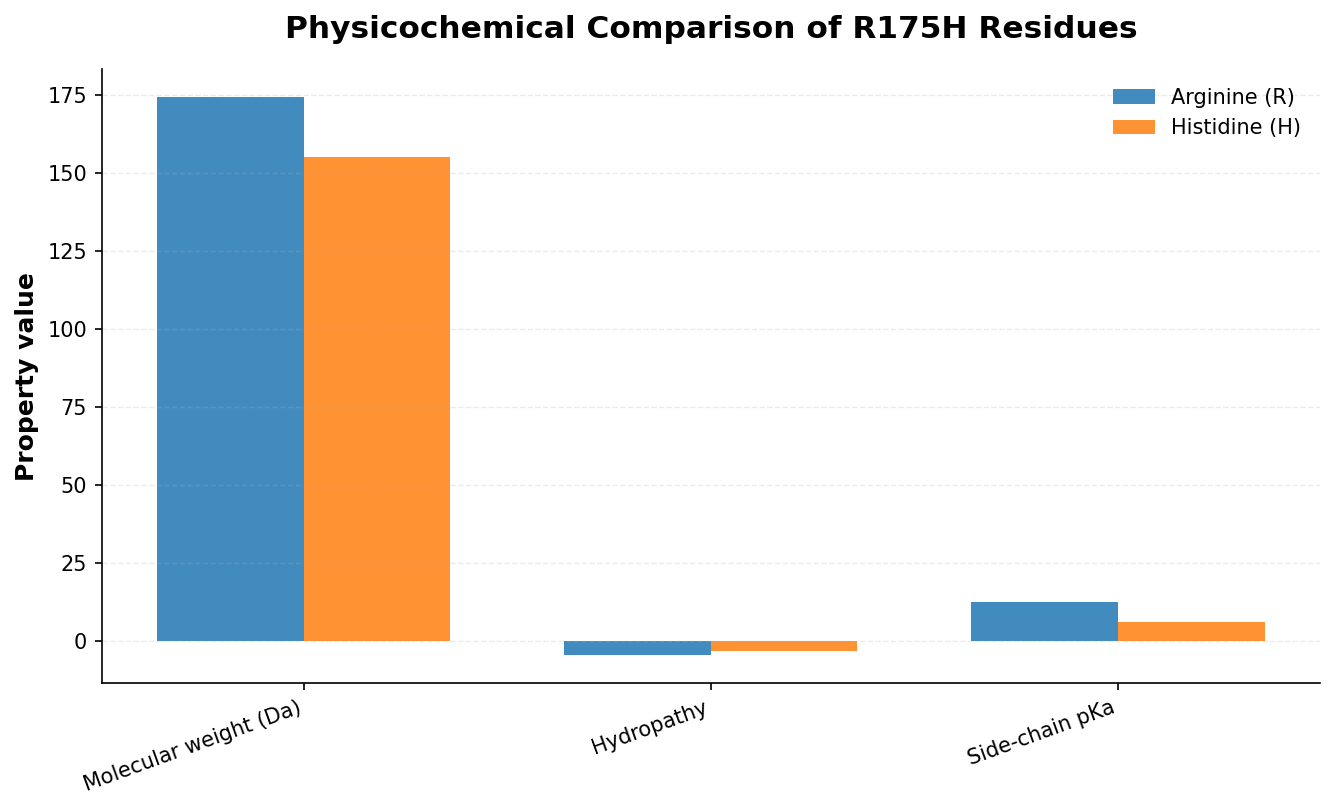

In [29]:
numeric_properties = pd.DataFrame({
    "Property": [
        "Molecular weight (Da)",
        "Hydropathy",
        "Side-chain pKa"
    ],
    "Arginine (R)": [
        residue_properties["R"]["Molecular_Weight"],
        residue_properties["R"]["Hydropathy"],
        residue_properties["R"]["pKa"]
    ],
    "Histidine (H)": [
        residue_properties["H"]["Molecular_Weight"],
        residue_properties["H"]["Hydropathy"],
        residue_properties["H"]["pKa"]
    ]
})

x = np.arange(len(numeric_properties))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150)

ax.bar(
    x - width / 2,
    numeric_properties["Arginine (R)"],
    width,
    label="Arginine (R)",
    alpha=0.85
)

ax.bar(
    x + width / 2,
    numeric_properties["Histidine (H)"],
    width,
    label="Histidine (H)",
    alpha=0.85
)

ax.set_xticks(x)
ax.set_xticklabels(
    numeric_properties["Property"],
    rotation=20,
    ha="right"
)

ax.set_ylabel(
    "Property value",
    fontsize=12,
    fontweight="bold"
)

ax.set_title(
    "Physicochemical Comparison of R175H Residues",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.legend(frameon=False)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "R175H_residue_property_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11. Protein-Level Physicochemical Comparison


We will calculate several sequence-level physicochemical properties for the complete wild-type and mutant proteins.

### Properties

* Molecular weight
* Isoelectric point
* GRAVY score
* Aromaticity
* Instability index



A single amino-acid substitution can produce measurable changes in overall sequence-derived protein properties.

These values provide quantitative features for comparing the reference and mutant proteins.

They are computational descriptors rather than direct experimental measurements of protein structure or function.


In [18]:
wt_analysis = ProteinAnalysis(wildtype_sequence)
mut_analysis = ProteinAnalysis(mutant_sequence)

protein_properties = pd.DataFrame({
    "Property": [
        "Molecular weight",
        "Isoelectric point",
        "GRAVY",
        "Aromaticity",
        "Instability index"
    ],
    "Wild_Type": [
        wt_analysis.molecular_weight(),
        wt_analysis.isoelectric_point(),
        wt_analysis.gravy(),
        wt_analysis.aromaticity(),
        wt_analysis.instability_index()
    ],
    "Mutant": [
        mut_analysis.molecular_weight(),
        mut_analysis.isoelectric_point(),
        mut_analysis.gravy(),
        mut_analysis.aromaticity(),
        mut_analysis.instability_index()
    ]
})

protein_properties["Change"] = (
    protein_properties["Mutant"]
    - protein_properties["Wild_Type"]
)

display(protein_properties)

,Property,Wild_Type,Mutant,Change
0,Molecular weight,43652.713400,43633.667000,-19.046400
1,Isoelectric point,6.331659,6.247822,-0.083838
2,GRAVY,-0.756234,-0.752926,0.003308
3,Aromaticity,0.061069,0.061069,0.000000
4,Instability index,73.592112,72.624682,-0.967430


## 12. Mutation Characterization



We will compare the residue properties before and after the substitution.


A substitution can preserve some biochemical characteristics while changing others.

For example, the wild-type and mutant residues can be compared according to:

* charge
* polarity
* residue identity

This provides a simple rule-based characterization of the observed substitution.

### Important note

This classification is based only on residue properties. It does not predict pathogenicity or establish whether the mutation is functionally damaging.


In [19]:
property_changes = {
    "Position": MUTATION_POSITION,
    "Wild_Type": wt_aa,
    "Mutant": mut_aa,
    "Wild_Type_Charge": wt_properties["charge"],
    "Mutant_Charge": mut_properties["charge"],
    "Wild_Type_Polarity": wt_properties["polarity"],
    "Mutant_Polarity": mut_properties["polarity"]
}

property_change_df = pd.DataFrame([property_changes])

display(property_change_df)

,Position,Wild_Type,Mutant,Wild_Type_Charge,Mutant_Charge,Wild_Type_Polarity,Mutant_Polarity
0,175,R,H,positive,positive,polar,polar


In [20]:
if wt_properties["charge"] == mut_properties["charge"]:
    charge_change = "No charge-category change"
else:
    charge_change = "Charge-category change"

if wt_properties["polarity"] == mut_properties["polarity"]:
    polarity_change = "No polarity-category change"
else:
    polarity_change = "Polarity-category change"

print("Mutation:", f"{wt_aa}{MUTATION_POSITION}{mut_aa}")
print(charge_change)
print(polarity_change)

Mutation: R175H
No charge-category change
No polarity-category change


## 13. Mutation Position Visualization



We will visualize the location of the mutation within the complete TP53 protein sequence.



A position-based visualization makes it easier to understand where the mutation occurs relative to the complete protein sequence.

The plot is a simple sequence-coordinate visualization rather than a three-dimensional structural prediction.


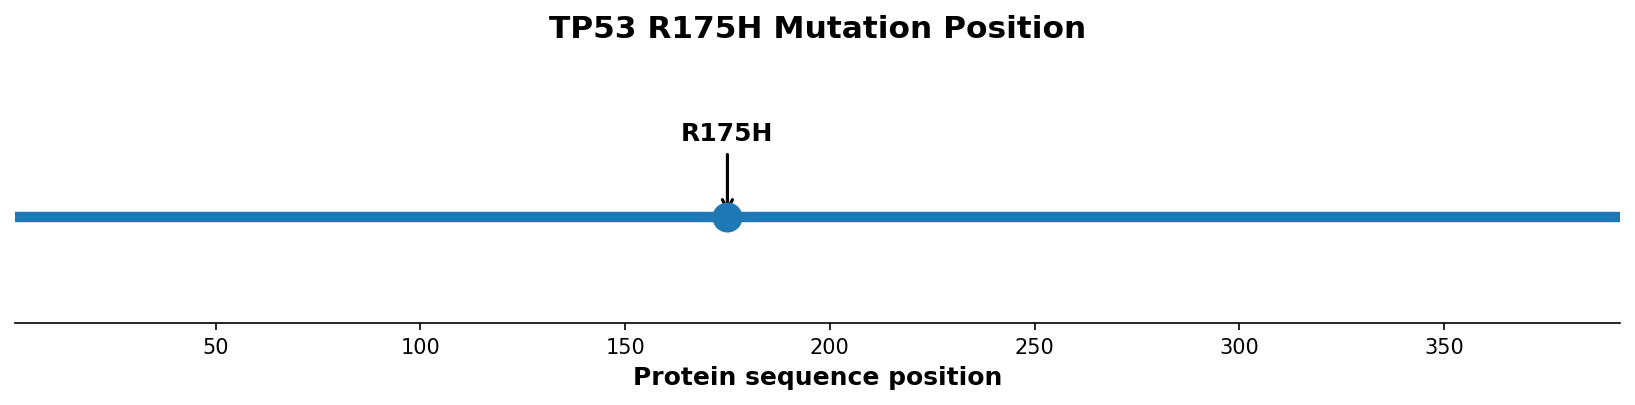

In [21]:
protein_length = len(wildtype_sequence)

fig, ax = plt.subplots(figsize=(11, 2.8), dpi=150)

ax.plot(
    [1, protein_length],
    [0, 0],
    linewidth=5
)

ax.scatter(
    MUTATION_POSITION,
    0,
    s=180,
    zorder=5
)

ax.annotate(
    f"R{MUTATION_POSITION}H",
    xy=(MUTATION_POSITION, 0),
    xytext=(MUTATION_POSITION, 0.18),
    ha="center",
    fontsize=12,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.5
    )
)

ax.set_xlim(1, protein_length)
ax.set_ylim(-0.25, 0.35)

ax.set_xlabel(
    "Protein sequence position",
    fontsize=12,
    fontweight="bold"
)

ax.set_yticks([])

ax.set_title(
    "TP53 R175H Mutation Position",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "tp53_R175H_position.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

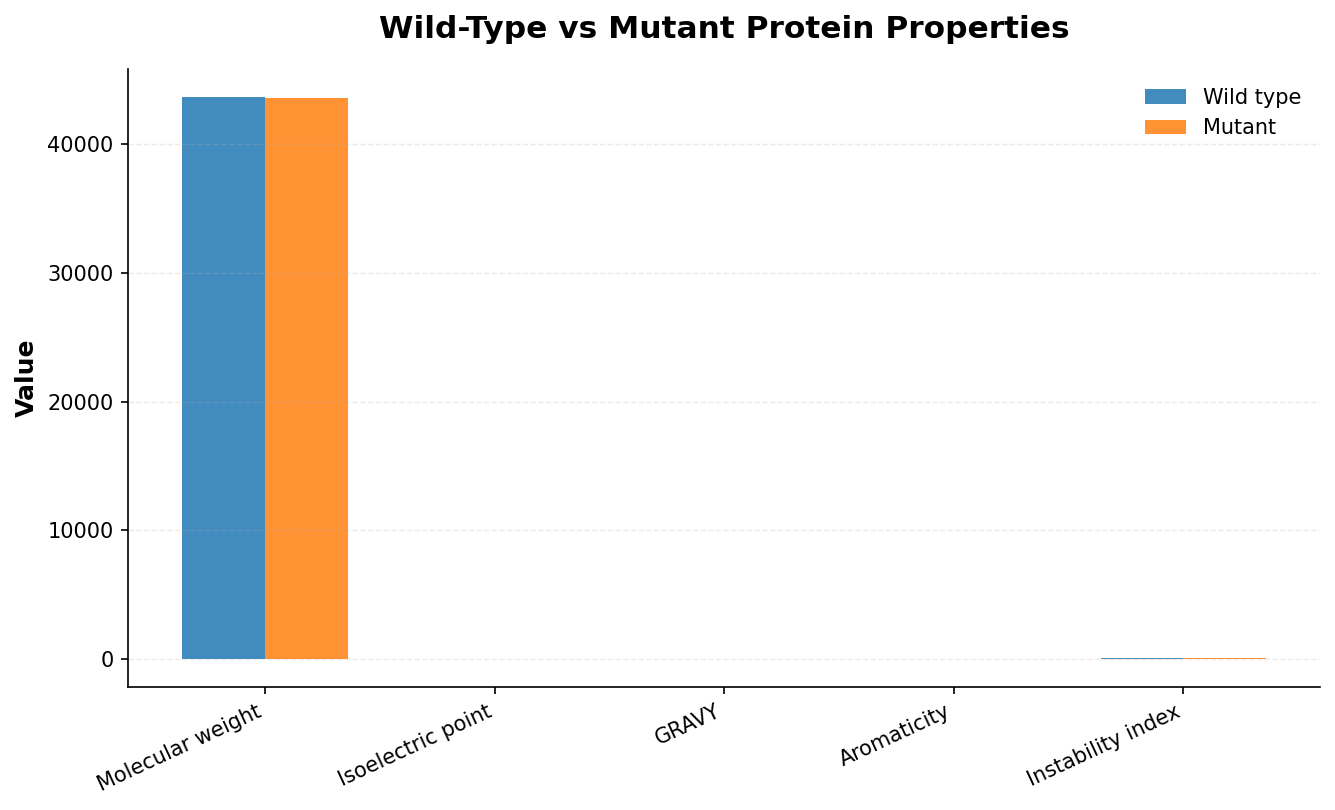

In [22]:
plot_df = protein_properties.copy()

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150)

x = np.arange(len(plot_df))
width = 0.36

ax.bar(
    x - width / 2,
    plot_df["Wild_Type"],
    width,
    label="Wild type",
    alpha=0.85
)

ax.bar(
    x + width / 2,
    plot_df["Mutant"],
    width,
    label="Mutant",
    alpha=0.85
)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_df["Property"],
    rotation=25,
    ha="right"
)

ax.set_ylabel(
    "Value",
    fontsize=12,
    fontweight="bold"
)

ax.set_title(
    "Wild-Type vs Mutant Protein Properties",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.legend(frameon=False)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "wildtype_vs_mutant_properties.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 14. Mutation Summary


We will combine the sequence comparison and physicochemical information into a single structured mutation report.

A structured report makes the analysis easier to inspect, export, and reuse in downstream computational workflows.

The report will contain the mutation position, amino-acid change, protein lengths, and sequence-level property information.


In [23]:
mutation_summary = {
    "Protein": "TP53",
    "UniProt_ID": UNIPROT_ID,
    "Variant": VARIANT_NAME,
    "Position": MUTATION_POSITION,
    "Wild_Type_Amino_Acid": wt_aa,
    "Mutant_Amino_Acid": mut_aa,
    "Wild_Type_Length": len(wildtype_sequence),
    "Mutant_Length": len(mutant_sequence),
    "Length_Change": len(mutant_sequence) - len(wildtype_sequence),
    "Charge_Change": charge_change,
    "Polarity_Change": polarity_change
}

mutation_summary_df = pd.DataFrame([mutation_summary])

display(mutation_summary_df.T)

,0
Protein,TP53
UniProt_ID,P04637
Variant,p.Arg175His (R175H)
Position,175
Wild_Type_Amino_Acid,R
Mutant_Amino_Acid,H
Wild_Type_Length,393
Mutant_Length,393
Length_Change,0
Charge_Change,No charge-category change


## 15. Exporting Results



We will save the main analysis results as CSV files.


Exported results allow the analysis to be reused outside the notebook and provide machine-readable outputs for future workflows.

The exported files can be included in the GitHub repository's results directory.


In [24]:
mutation_df.to_csv(
    "mutation_comparison.csv",
    index=False
)

protein_properties.to_csv(
    "protein_property_comparison.csv",
    index=False
)

property_change_df.to_csv(
    "amino_acid_property_change.csv",
    index=False
)

mutation_summary_df.to_csv(
    "mutation_summary.csv",
    index=False
)

print("Analysis results exported successfully.")

Analysis results exported successfully.


In [25]:
with open("protein_mutation_report.txt", "w") as file:

    file.write("Protein Mutation Analyzer Report\n")
    file.write("=" * 45 + "\n\n")

    file.write(f"Protein: TP53\n")
    file.write(f"UniProt ID: {UNIPROT_ID}\n")
    file.write(f"Variant: {VARIANT_NAME}\n")
    file.write(f"Position: {MUTATION_POSITION}\n")
    file.write(f"Wild-type residue: {wt_aa}\n")
    file.write(f"Mutant residue: {mut_aa}\n\n")

    file.write("Sequence Information\n")
    file.write("-" * 45 + "\n")
    file.write(
        f"Wild-type length: {len(wildtype_sequence)} aa\n"
    )
    file.write(
        f"Mutant length: {len(mutant_sequence)} aa\n"
    )

    file.write("\nResidue Property Changes\n")
    file.write("-" * 45 + "\n")
    file.write(f"Charge: {charge_change}\n")
    file.write(f"Polarity: {polarity_change}\n")

    file.write("\nProtein-Level Properties\n")
    file.write("-" * 45 + "\n")

    for _, row in protein_properties.iterrows():
        file.write(
            f"{row['Property']}: "
            f"WT={row['Wild_Type']:.4f}, "
            f"Mutant={row['Mutant']:.4f}, "
            f"Change={row['Change']:.4f}\n"
        )

print("Text report created successfully.")

Text report created successfully.


## 16. Final Analysis Summary

The Protein Mutation Analyzer successfully completed a protein-level comparison between the TP53 wild-type reference sequence and the R175H mutant sequence.

The workflow:

1. Retrieved a real TP53 reference sequence from UniProt.
2. Validated the expected residue at position 175.
3. Generated the R175H mutant sequence.
4. Compared wild-type and mutant sequences.
5. Identified the amino-acid substitution.
6. Checked for sequence-length changes.
7. Compared residue-level biochemical properties.
8. Calculated whole-protein physicochemical descriptors.
9. Visualized the mutation position.
10. Generated structured CSV and text reports.

The workflow is designed to be reusable with other protein sequences and amino-acid variants.

### Interpretation

The analysis provides computational evidence describing the sequence and physicochemical differences between the reference and mutant proteins.

However, sequence-level property changes alone do not establish structural effects, biological function, or clinical significance. Those questions require additional experimental or computational evidence.


In [26]:
print("=" * 60)
print("PROTEIN MUTATION ANALYZER — FINAL SUMMARY")
print("=" * 60)

print(f"Protein: TP53 ({UNIPROT_ID})")
print(f"Reference length: {len(wildtype_sequence)} aa")
print(f"Variant: {VARIANT_NAME}")
print(f"Mutation position: {MUTATION_POSITION}")
print(f"Wild-type residue: {wt_aa}")
print(f"Mutant residue: {mut_aa}")
print(f"Number of substitutions detected: {len(mutation_df)}")
print(f"Length change: {len(mutant_sequence) - len(wildtype_sequence)} aa")
print(f"Charge comparison: {charge_change}")
print(f"Polarity comparison: {polarity_change}")

print("\nAnalysis completed successfully.")

PROTEIN MUTATION ANALYZER — FINAL SUMMARY
Protein: TP53 (P04637)
Reference length: 393 aa
Variant: p.Arg175His (R175H)
Mutation position: 175
Wild-type residue: R
Mutant residue: H
Number of substitutions detected: 1
Length change: 0 aa
Charge comparison: No charge-category change
Polarity comparison: No polarity-category change

Analysis completed successfully.


# 17. Conclusion

This notebook demonstrates a reproducible protein mutation-analysis workflow using a real human protein and a documented amino-acid variant.

The project combines biological sequence retrieval, validation, mutation detection, physicochemical analysis, visualization, and automated result generation.

Although TP53 R175H was used as the demonstration case, the underlying functions are designed to be reusable for other protein sequences and amino-acid substitutions.


